# Sentiment Analysis LSTM + Evaluasi Detail + Visualisasi
Dataset: Instagram Comments (Bahasa Indonesia + Emoji)


In [23]:
!pip install pandas numpy scikit-learn tensorflow emoji matplotlib

In [24]:
import pandas as pd
import numpy as np
import re, random
import emoji
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

## Load & Prepare Data

In [25]:
df = pd.read_csv('/content/Data_Gabungan.csv')
df = df[['Isi_Komentar','Sentimen']].dropna()

df['label_enc'] = df['Sentimen'].apply(lambda x: 0 if x==-1 else (1 if x==0 else 2))

## PREPROCESSING

In [26]:
def clean_text(text):
    text = str(text).lower()
    text = emoji.demojize(text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s:]', ' ', text)
    return text

df['clean'] = df['Isi_Komentar'].apply(clean_text)

## AUGMENTASI

In [27]:
def random_swap(text):
    words = text.split()
    if len(words) < 2:
        return text
    i, j = random.sample(range(len(words)), 2)
    words[i], words[j] = words[j], words[i]
    return ' '.join(words)

def random_deletion(text, p=0.2):
    words = text.split()
    if len(words) == 1:
        return text
    new_words = [w for w in words if random.random() > p]
    return ' '.join(new_words)

df_pos = df[df['label_enc'] == 2]

aug1 = df_pos.copy()
aug1['clean'] = aug1['clean'].apply(random_swap)

aug2 = df_pos.copy()
aug2['clean'] = aug2['clean'].apply(random_deletion)

df = pd.concat([df, aug1, aug2])

## Tokenization

In [28]:
tokenizer = Tokenizer(num_words=12000, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean'])

seq = tokenizer.texts_to_sequences(df['clean'])
pad = pad_sequences(seq, maxlen=100, padding='post')

## Split Data

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    pad, df['label_enc'], test_size=0.2, random_state=42
)

## Model BiLSTM

In [30]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

model = Sequential([
    Embedding(12000, 128),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

optimizer = Adam(learning_rate=0.0005)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=2,
#     restore_best_weights=True
# )

{0: np.float64(1.2588439460686156), 1: np.float64(1.0530429927414853), 2: np.float64(0.7961837217156366)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## Training

In [31]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weights,
    # callbacks=[early_stop]
)

Epoch 1/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 93s 163ms/step - accuracy: 0.6157 - loss: 0.8384 - val_accuracy: 0.7550 - val_loss: 0.6021
Epoch 2/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 77s 144ms/step - accuracy: 0.7815 - loss: 0.5667 - val_accuracy: 0.7874 - val_loss: 0.5222
Epoch 3/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 81s 143ms/step - accuracy: 0.8482 - loss: 0.4272 - val_accuracy: 0.7996 - val_loss: 0.5396
Epoch 4/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 76s 143ms/step - accuracy: 0.8783 - loss: 0.3542 - val_accuracy: 0.8006 - val_loss: 0.5777


## Evaluasi Detail

In [32]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_classes,
    target_names=['Negatif','Netral','Positif'],
    digits=4
))

148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step
Confusion Matrix:
[[ 824  297  109]
 [ 256 1072  126]
 [  98  153 1780]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.6995    0.6699    0.6844      1230
      Netral     0.7043    0.7373    0.7204      1454
     Positif     0.8834    0.8764    0.8799      2031

    accuracy                         0.7796      4715
   macro avg     0.7624    0.7612    0.7616      4715
weighted avg     0.7802    0.7796    0.7797      4715



## Hitung TP, FP, FN per kelas

In [33]:
for i, label in enumerate(['Negatif','Netral','Positif']):
    TP = cm[i][i]
    FP = cm[:,i].sum() - TP
    FN = cm[i,:].sum() - TP
    print(f"{label} -> TP:{TP}, FP:{FP}, FN:{FN}")

Negatif -> TP:824, FP:354, FN:406
Netral -> TP:1072, FP:450, FN:382
Positif -> TP:1780, FP:235, FN:251


## Visualisasi Training

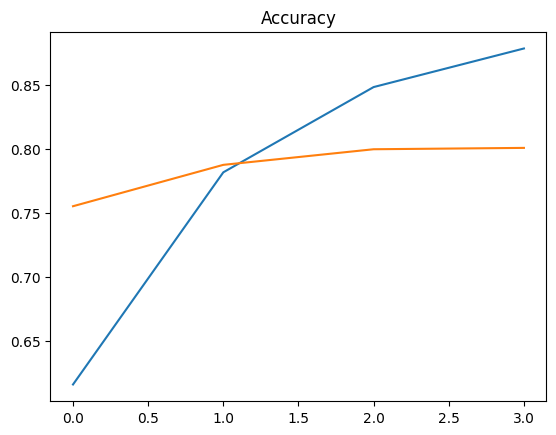

In [34]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.show()

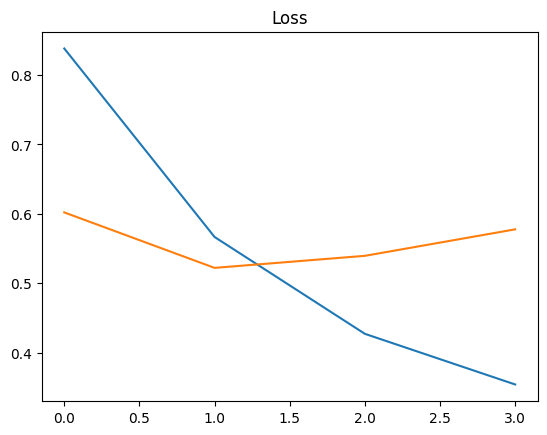

In [35]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.show()